In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
df=pd.read_csv("cleaned_dataset.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  str    
 1   Item              9031 non-null   str    
 2   Quantity          9962 non-null   float64
 3   Price Per Unit    9962 non-null   float64
 4   Total Spent       9960 non-null   float64
 5   Payment Method    6822 non-null   str    
 6   Location          6039 non-null   str    
 7   Transaction Date  9540 non-null   str    
dtypes: float64(3), str(5)
memory usage: 625.1 KB


Total Revenue

In [5]:
# Total Spent: missing values are excluded, the result may underestimate the value.
# Actual total revenue may be higher due to unrecoverable missing values.
df["Total Spent"].sum()

np.float64(88952.0)

Total Transactions

In [6]:
df["Transaction ID"].nunique()

10000

Total Quantity Sold

In [7]:
df["Quantity"].sum()

np.float64(30141.0)

Average Transaction Value

In [8]:
df["Total Spent"].mean()

np.float64(8.930923694779116)

Average Quantity per Transaction

In [9]:
df["Quantity"].mean()

np.float64(3.025597269624573)

Product Performance

In [12]:
print(df.groupby("Item")["Quantity"].sum())

Item
Cake        3462.0
Coffee      3534.0
Cookie      3228.0
Juice       3505.0
Salad       3468.0
Sandwich    3424.0
Smoothie    3330.0
Tea         3292.0
Name: Quantity, dtype: float64


In [20]:
df.groupby("Item")["Quantity"].sum().sort_values(ascending=False)

Item
Coffee      3534.0
Juice       3505.0
Salad       3468.0
Cake        3462.0
Sandwich    3424.0
Smoothie    3330.0
Tea         3292.0
Cookie      3228.0
Name: Quantity, dtype: float64

In [22]:
revenue_by_product=df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)
print(revenue_by_product)

Item
Salad       17320.0
Sandwich    13664.0
Smoothie    13320.0
Juice       10509.0
Cake        10395.0
Coffee       7062.0
Tea          4951.5
Cookie       3223.0
Name: Total Spent, dtype: float64


<Axes: title={'center': 'Revenue By Product'}, xlabel='Item'>

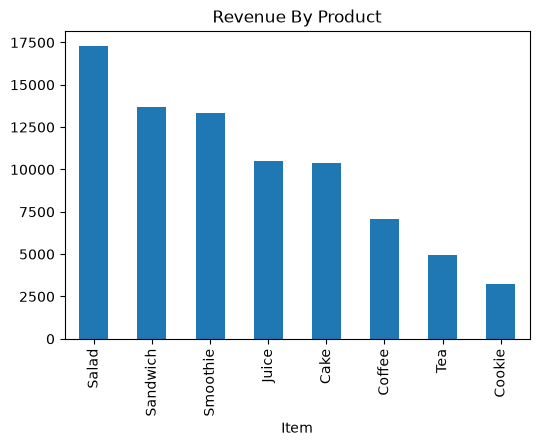

In [39]:
revenue_by_product.plot.bar(
    title="Revenue By Product",
    figsize=(6,4))

Payment Method

In [27]:
pm_occurrence=df["Payment Method"].value_counts()
print(pm_occurrence)

Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64


<Axes: title={'center': 'Payment Method'}>

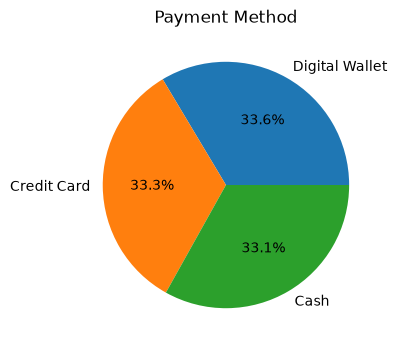

In [41]:
pm_occurrence.plot.pie(
    figsize=(4,4),autopct="%1.1f%%", title="Payment Method"
)

Time Trends

In [42]:
df["Transaction Date"]=pd.to_datetime(df["Transaction Date"],errors="coerce")

In [44]:
df["Month"]=df["Transaction Date"].dt.month

In [47]:
monthly_revenue=df.groupby("Month")["Total Spent"].sum()
monthly_revenue

Month
1.0     7242.0
2.0     6633.5
3.0     7214.5
4.0     7168.0
5.0     6941.5
6.0     7350.0
7.0     6877.5
8.0     7077.5
9.0     6846.0
10.0    7302.0
11.0    6957.0
12.0    7177.0
Name: Total Spent, dtype: float64

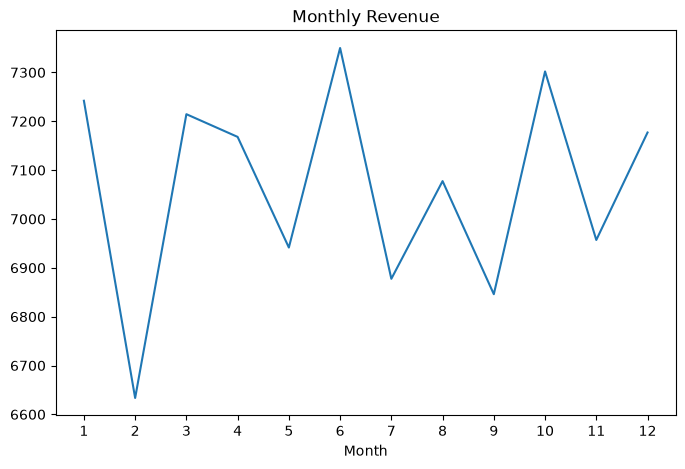

In [52]:
monthly_revenue.plot(
    kind='line',
    figsize=(8,5),
    title="Monthly Revenue"
    )
plt.xticks(range(1, 13))
plt.show()

In [61]:
monthly_transactions=df.groupby("Month")["Transaction ID"].count()
print(monthly_transactions)

Month
1.0     818
2.0     727
3.0     827
4.0     774
5.0     777
6.0     818
7.0     791
8.0     803
9.0     788
10.0    838
11.0    784
12.0    795
Name: Transaction ID, dtype: int64


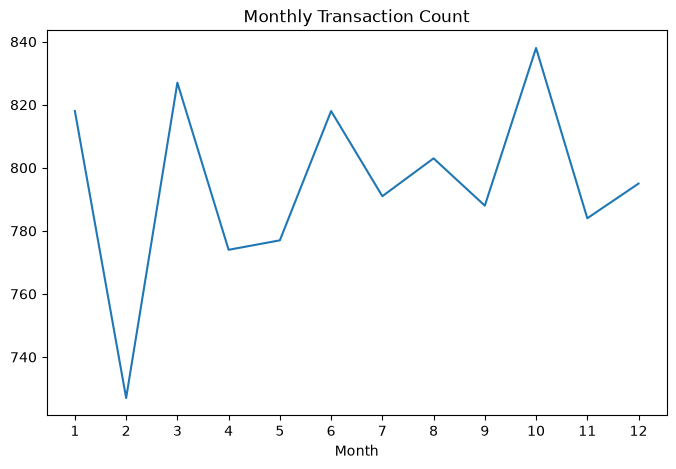

In [62]:
monthly_transactions.plot(
    kind="line",
    figsize=(8, 5),
    title="Monthly Transaction Count"
)

plt.xticks(range(1, 13))
plt.show()